In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/MyDrive/'))

Mounted at /content/drive
['Mine', 'Colab Notebooks', 'petclass.zip', 'Copy of petclass.zip', '1000031508.jpg', '1000031509.jpg', '1000036118.jpg', '1000031497.jpg', '1000031494.jpg', '1000031489.jpg', '1000031493.jpg', '1000031491.jpg', '1000031490.jpg', '1000031505.jpg', '1000037500.jpg', '1000036308.jpg', '1000037501.mp4', 'catvsdog.ipynb']


In [2]:
import zipfile

with zipfile.ZipFile(
    '/content/drive/MyDrive/petclass.zip',
    'r') as zip_ref:
    zip_ref.extractall('/content/PetImages')

print("done!")
os.listdir('/content/PetImages')

done!


['PetImages']

In [3]:
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/'))

['Copy of catvsdogusingTL.ipynb', 'catvsdogusingTL.ipynb']


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from PIL import ImageFile

# Allow partially damaged images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -----------------------------------
# DEVICE
# -----------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------------
# TRAIN TRANSFORMS
# -----------------------------------

train_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

# -----------------------------------
# TEST TRANSFORMS
# -----------------------------------

test_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

# -----------------------------------
# LOAD DATASETS
# -----------------------------------

train_dataset = datasets.ImageFolder(
    root='/content/PetImages/PetImages',
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root='/content/PetImages/PetImages',
    transform=test_transform
)

# -----------------------------------
# TRAIN / TEST SPLIT
# -----------------------------------

train_size = int(0.8 * len(train_dataset))
test_size = len(train_dataset) - train_size

indices = torch.randperm(len(train_dataset)).tolist()

train_subset =torch.utils.data. Subset(
    train_dataset,
    indices[:train_size]
)

test_subset = torch.utils.data.Subset(
    test_dataset,
    indices[train_size:]
)

# -----------------------------------
# DATALOADERS
# -----------------------------------

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_subset))
print("Testing images:", len(test_subset))

# -----------------------------------
# CNN MODEL
# -----------------------------------

class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Conv Block 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

    def forward(self, x):

        # Block 1
        x = self.pool(
            F.relu(
                self.bn1(
                    self.conv1(x)
                )
            )
        )

        # Block 2
        x = self.pool(
            F.relu(
                self.bn2(
                    self.conv2(x)
                )
            )
        )

        # Block 3
        x = self.pool(
            F.relu(
                self.bn3(
                    self.conv3(x)
                )
            )
        )

        # Flatten
        x = x.view(x.size(0), -1)

        # FC 1
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # FC 2
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # Output
        x = self.fc3(x)

        return x

# MODEL
if 'model' in dir():
    del model
    torch.cuda.empty_cache()



# -----------------------------------
# MODEL
# -----------------------------------

model = CNN().to(device)

# -----------------------------------
# LOSS FUNCTION
# -----------------------------------

criterion = nn.CrossEntropyLoss()

# -----------------------------------
# OPTIMIZER
# -----------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# -----------------------------------
# TRAINING
# -----------------------------------

epochs = 20

for epoch in range(epochs):

    # ---------------- TRAIN ----------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    # ---------------- TEST ----------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total

    # ---------------- PRINT ----------------

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Test Accuracy: {test_accuracy:.2f}%"
    )

# -----------------------------------
# SAVE MODEL
# -----------------------------------

torch.save(model.state_dict(), "catvsdog.pth")

print("Model saved!")

Using device: cuda
Classes: ['Cat', 'Dog']
Training images: 19998
Testing images: 5000


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/20] Loss: 0.7378 Train Accuracy: 51.95% Test Accuracy: 50.90%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/20] Loss: 0.6890 Train Accuracy: 51.91% Test Accuracy: 61.00%


...

Epoch [18/20] Loss: 0.3248 Train Accuracy: 86.22% Test Accuracy: 88.10%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [19/20] Loss: 0.3156 Train Accuracy: 86.67% Test Accuracy: 87.82%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [20/20] Loss: 0.3011 Train Accuracy: 87.30% Test Accuracy: 88.92%
Model saved!


In [5]:
print(train_subset.dataset is test_subset.dataset)

False


upload a cat or dog image!


Saving Screenshot 2026-05-27 232233.png to Screenshot 2026-05-27 232233.png


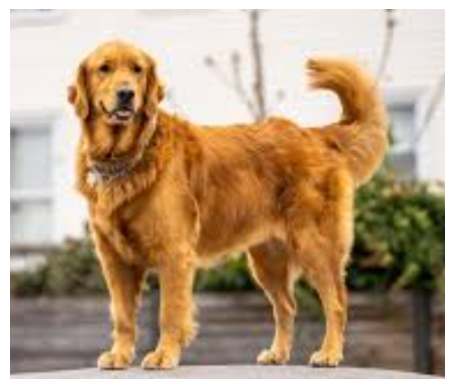

Prediction : Dog
Confidence : 98.04%


In [6]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

print("upload a cat or dog image!")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image    = Image.open(filename).convert("RGB")

plt.imshow(image)
plt.axis('off')
plt.show()

transform_pred = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

img_tensor = transform_pred(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output    = model(img_tensor)
    _, predicted = torch.max(output, 1)

    classes    = ['Cat', 'Dog']
    result     = classes[predicted.item()]

    probs      = torch.softmax(output, dim=1)
    confidence = probs[0][predicted.item()].item() * 100

print(f"Prediction : {result}")
print(f"Confidence : {confidence:.2f}%")

In [8]:
!git status

fatal: not a git repository (or any of the parent directories): .git
